# Principal Component Analysis (PCA) Demonstration

This notebook provides a comprehensive demonstration of Principal Component Analysis (PCA), a dimensionality reduction technique widely used in data science and machine learning.

## What is PCA?

Principal Component Analysis is a statistical procedure that uses an orthogonal transformation to convert a set of observations of possibly correlated variables into a set of values of linearly uncorrelated variables called principal components. The transformation is defined in such a way that the first principal component has the largest possible variance, and each succeeding component has the highest variance possible under the constraint that it is orthogonal to the preceding components.

## Outline of this Notebook

1. Generate synthetic data to visualize PCA
2. Implement PCA from scratch
3. Use scikit-learn's PCA implementation
4. Apply PCA to a real-world dataset (Iris)
5. Determine the optimal number of components
6. Image compression with PCA

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris, fetch_olivetti_faces
from mpl_toolkits.mplot3d import Axes3D

# Set random seed for reproducibility
np.random.seed(42)

## 1. Generate Synthetic Data for PCA Visualization

We'll create a 2D dataset with a clear directional variance to demonstrate how PCA identifies principal components.

C:\Users\MUICT\AppData\Local\Temp\ipykernel_16240\147874123.py:9: RuntimeWarning: covariance is not positive-semidefinite.
  data = np.random.multivariate_normal(mean, cov, n_samples)


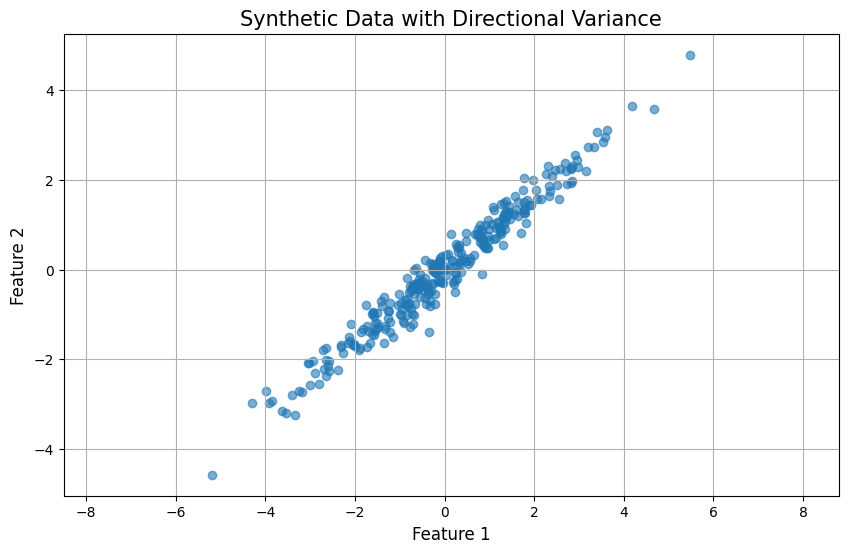

In [2]:
# Generate synthetic data with a specific covariance structure
def generate_correlated_data(n_samples=300):
    # Create a covariance matrix
    cov = np.array([[3, 2.5],
                    [2.5, 2]])
    
    # Generate random data with this covariance structure
    mean = [0, 0]
    data = np.random.multivariate_normal(mean, cov, n_samples)
    
    return data

# Generate our synthetic data
X = generate_correlated_data()

# Visualize the raw data
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.6)
plt.title('Synthetic Data with Directional Variance', fontsize=15)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.grid(True)
plt.axis('equal')
plt.show()

## 2. Using scikit-learn's PCA Implementation

Now let's use the built-in PCA implementation from scikit-learn and compare with our from-scratch implementation.

Explained variance ratio (sklearn):
PC1: 99.0181%
PC2: 0.9819%


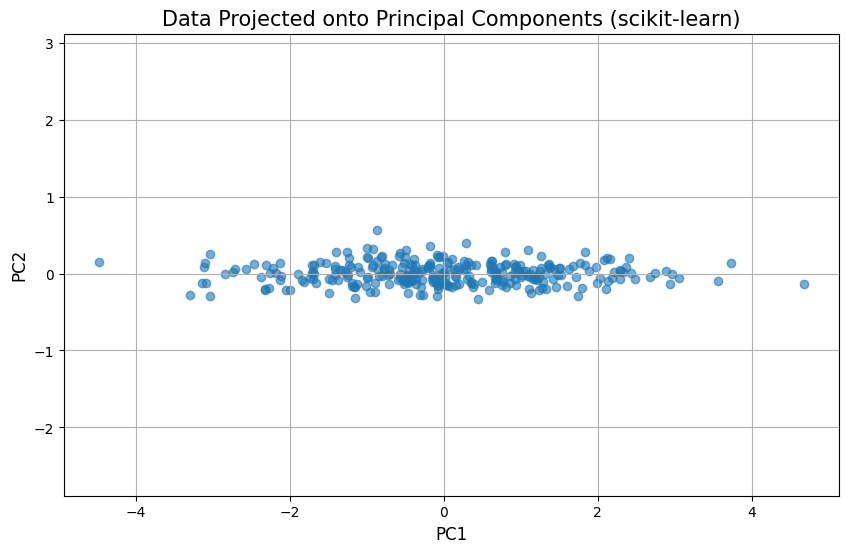

In [3]:
# Standardize the data
X_std = StandardScaler().fit_transform(X)

# Apply PCA using scikit-learn
pca = PCA(n_components=2)
X_pca_sklearn = pca.fit_transform(X_std)

# Print explained variance ratio
print("Explained variance ratio (sklearn):")
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {ratio:.4%}")

# Visualize the projected data from sklearn's PCA
plt.figure(figsize=(10, 6))
plt.scatter(X_pca_sklearn[:, 0], X_pca_sklearn[:, 1], alpha=0.6)
plt.title('Data Projected onto Principal Components (scikit-learn)', fontsize=15)
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.grid(True)
plt.axis('equal')
plt.show()

## 3. Apply PCA to a Real-World Dataset: Iris

Now let's apply PCA to the classic Iris dataset to see how it can help visualize high-dimensional data.

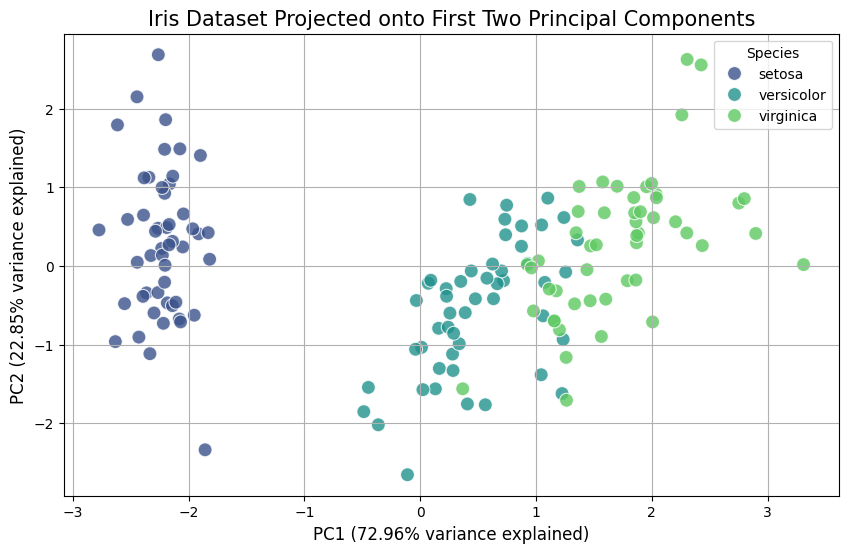

In [4]:
# Load the Iris dataset
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Standardize the data
X_iris_std = StandardScaler().fit_transform(X_iris)

# Apply PCA
pca_iris = PCA(n_components=2)
X_iris_pca = pca_iris.fit_transform(X_iris_std)

# Create a DataFrame for easier plotting
pca_df = pd.DataFrame(data=X_iris_pca, columns=['PC1', 'PC2'])
pca_df['target'] = y_iris
pca_df['species'] = pca_df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# Visualize the projected data colored by species
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue='species', data=pca_df, palette='viridis', s=100, alpha=0.8)
plt.title('Iris Dataset Projected onto First Two Principal Components', fontsize=15)
plt.xlabel(f'PC1 ({pca_iris.explained_variance_ratio_[0]:.2%} variance explained)', fontsize=12)
plt.ylabel(f'PC2 ({pca_iris.explained_variance_ratio_[1]:.2%} variance explained)', fontsize=12)
plt.grid(True)
plt.legend(title='Species')
plt.show()

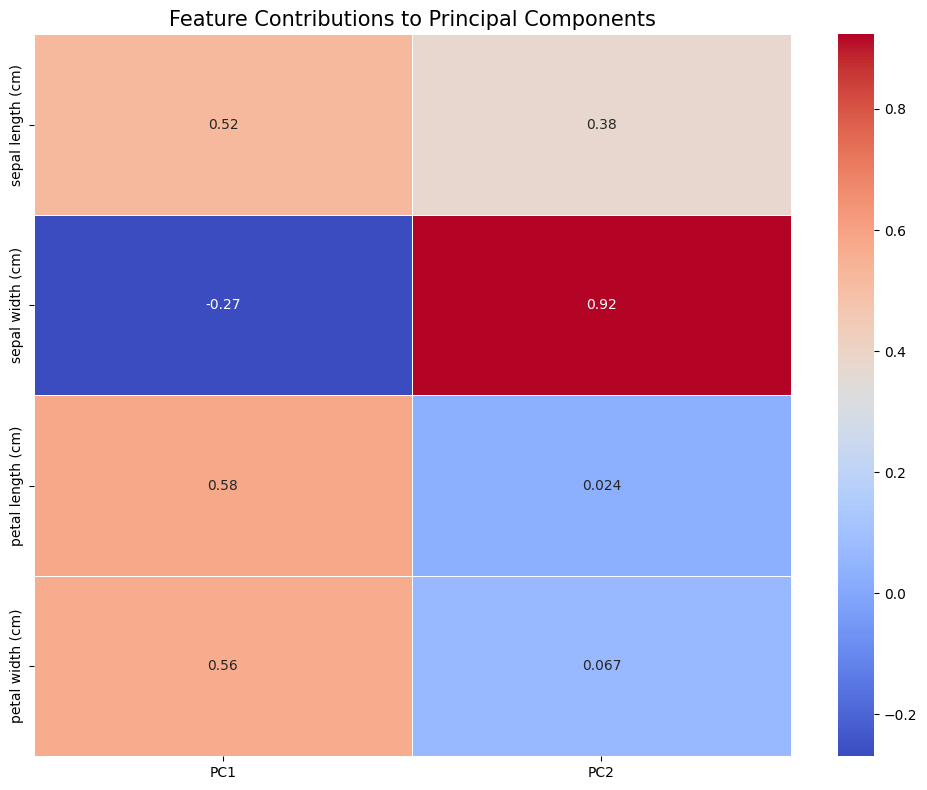

In [5]:
# Visualize feature contributions to each principal component
feature_names = iris.feature_names
components = pd.DataFrame(pca_iris.components_.T, 
                         columns=['PC1', 'PC2'], 
                         index=feature_names)

plt.figure(figsize=(10, 8))
sns.heatmap(components, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Contributions to Principal Components', fontsize=15)
plt.tight_layout()
plt.show()

## 4. Determining the Optimal Number of Components

A key question in PCA is how many components to retain. We can use the explained variance ratio to determine this.

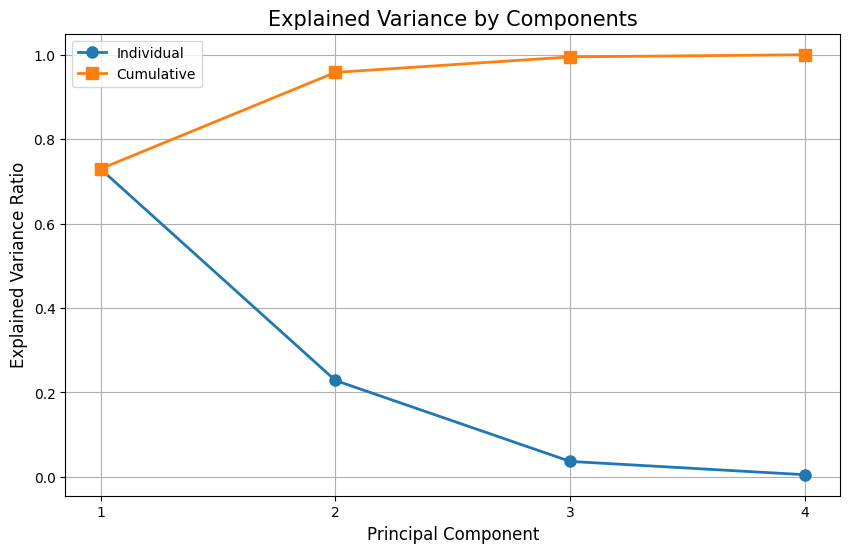

In [6]:
# Apply PCA with all components
pca_full = PCA()
pca_full.fit(X_iris_std)

# Plot the explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca_full.explained_variance_ratio_) + 1), 
         pca_full.explained_variance_ratio_, 'o-', linewidth=2, markersize=8)
plt.plot(range(1, len(pca_full.explained_variance_ratio_) + 1),
         np.cumsum(pca_full.explained_variance_ratio_), 's-', linewidth=2, markersize=8)
plt.title('Explained Variance by Components', fontsize=15)
plt.xlabel('Principal Component', fontsize=12)
plt.ylabel('Explained Variance Ratio', fontsize=12)
plt.grid(True)
plt.legend(['Individual', 'Cumulative'])
plt.xticks(range(1, len(pca_full.explained_variance_ratio_) + 1))
plt.show()

## 5. Image Compression with PCA

One practical application of PCA is image compression. We'll demonstrate this using the Olivetti faces dataset.

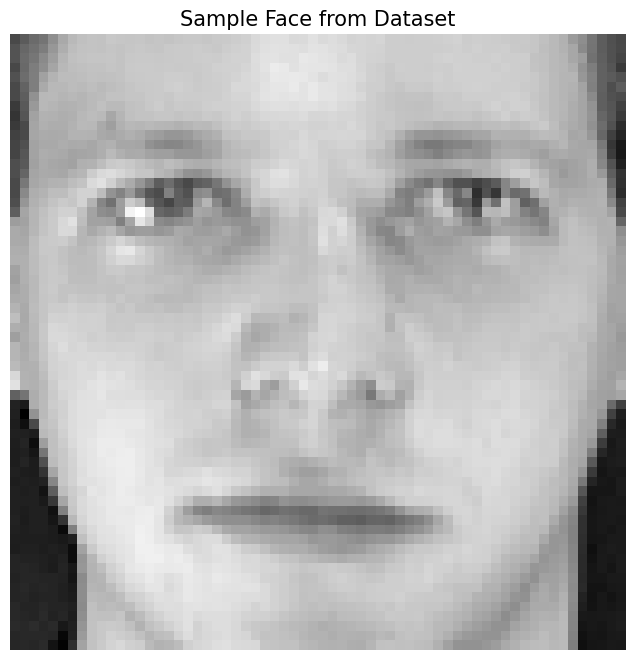

In [7]:
# Load the Olivetti faces dataset
faces = fetch_olivetti_faces()
X_faces = faces.data

# Display a sample face
def plot_face(face_data, title):
    face = face_data.reshape(64, 64)
    plt.imshow(face, cmap='gray')
    plt.title(title, fontsize=15)
    plt.axis('off')

plt.figure(figsize=(8, 8))
plot_face(X_faces[0], 'Sample Face from Dataset')
plt.show()

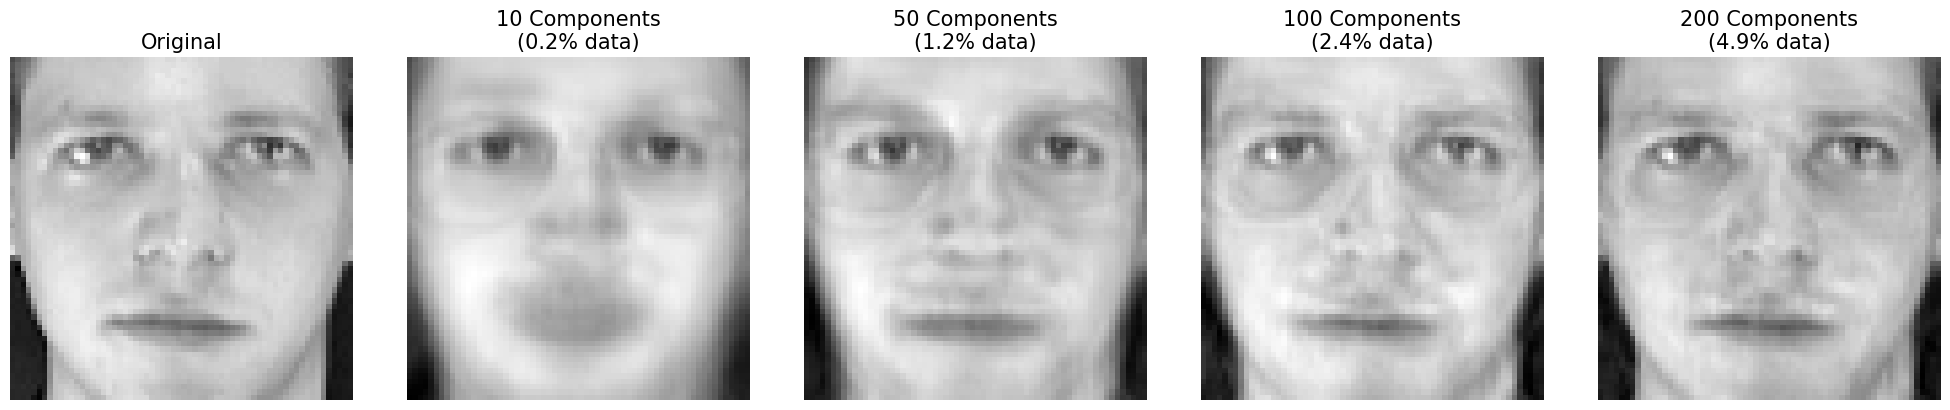

In [8]:
# Apply PCA with different number of components for image compression
n_components_list = [10, 50, 100, 200]
fig, axes = plt.subplots(1, len(n_components_list) + 1, figsize=(20, 4))

# Original image
plot_face(X_faces[0], 'Original')
plt.sca(axes[0])
plot_face(X_faces[0], 'Original')

# Reconstruct with different number of components
for i, n_components in enumerate(n_components_list):
    # Apply PCA
    pca = PCA(n_components=n_components)
    X_faces_pca = pca.fit_transform(X_faces)
    X_faces_reconstructed = pca.inverse_transform(X_faces_pca)
    
    # Plot the reconstructed image
    plt.sca(axes[i+1])
    plot_face(X_faces_reconstructed[0], f'{n_components} Components\n({n_components/4096:.1%} data)')

plt.tight_layout()
plt.show()

## Conclusion

In this notebook, we've explored Principal Component Analysis (PCA) from multiple angles:

1. We implemented PCA from scratch to understand the underlying mathematics
2. We used scikit-learn's implementation for efficiency
3. We applied PCA to visualize the Iris dataset
4. We determined the optimal number of components using the explained variance ratio
5. We demonstrated image compression with PCA

PCA is a powerful technique for dimensionality reduction, data visualization, and feature extraction. By projecting high-dimensional data onto a lower-dimensional subspace that captures most of the variance, PCA helps us understand the underlying structure of our data and can improve the performance of many machine learning algorithms.